Устройство: cpu
Файл данных: S12-hw-dataset.csv

Sanity-check по данным
Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски по колонкам:
date      0
target    0
dtype: int64
Общее число пропусков: 0


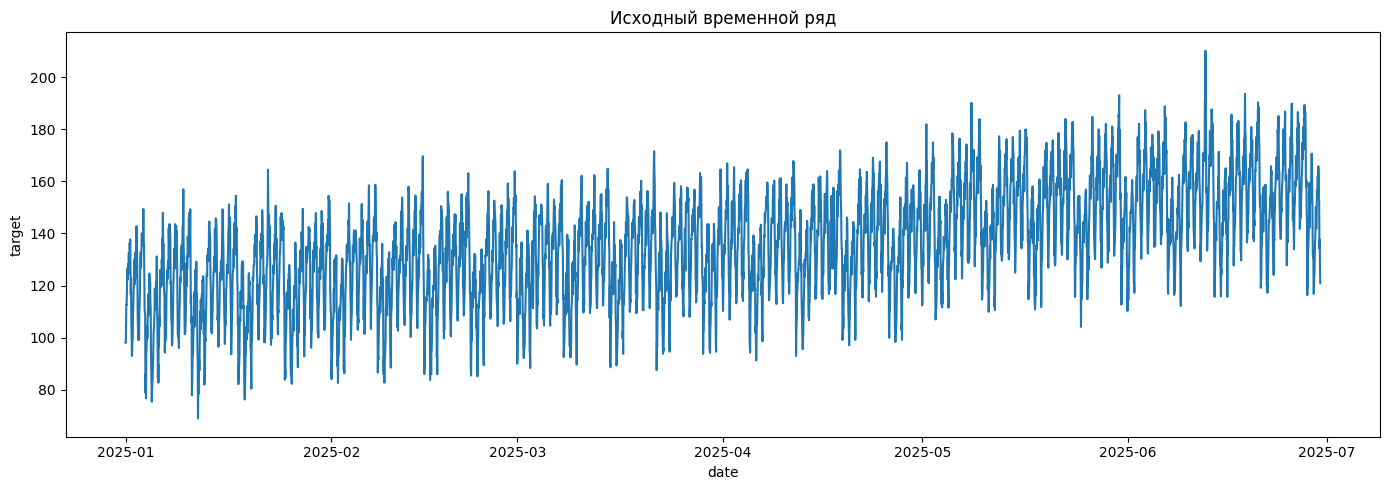


Почему random split некорректен для временного ряда:
При случайном разбиении модель может обучаться на будущих наблюдениях относительно validation/test,
что создаёт leakage и делает оценку качества некорректной.
Поэтому здесь используется только chronological temporal split без shuffle.

Границы temporal split
train: 2025-01-01 00:00:00 — 2025-05-06 23:00:00 (3024 строк)
validation: 2025-05-07 00:00:00 — 2025-06-02 23:00:00 (648 строк)
test: 2025-06-03 00:00:00 — 2025-06-29 23:00:00 (648 строк)


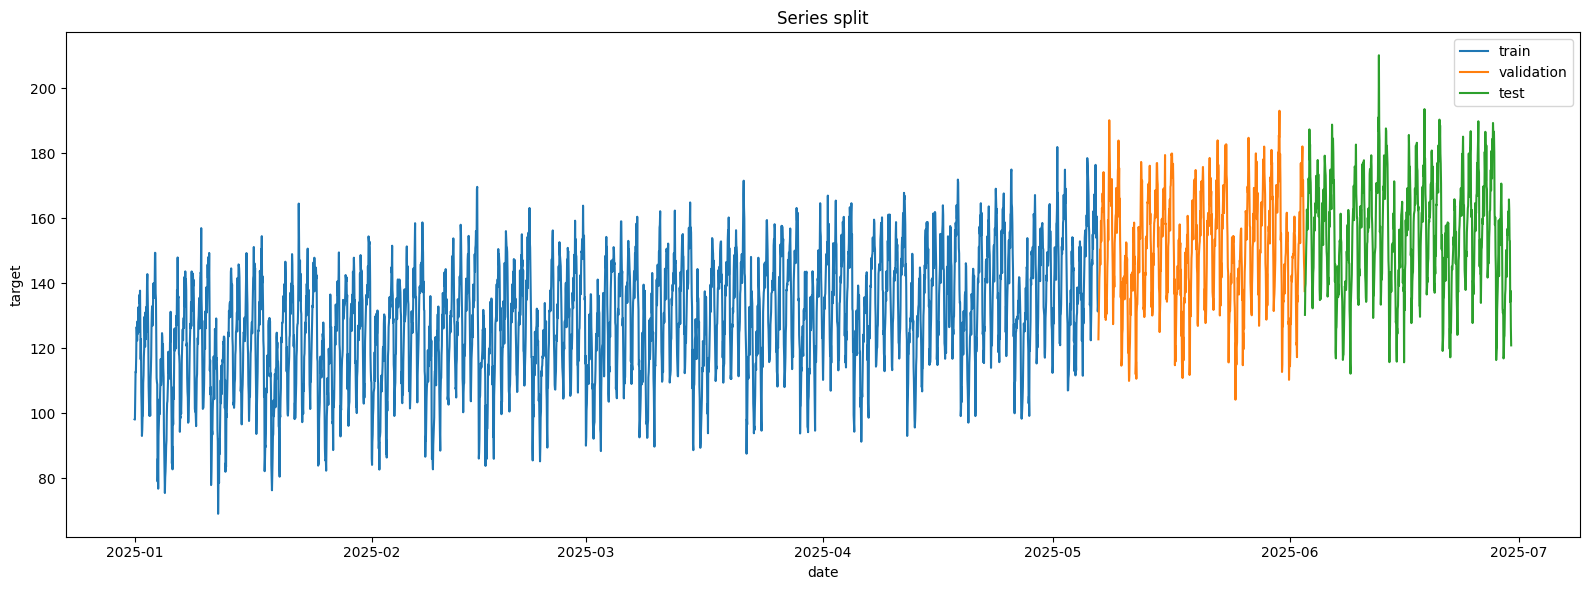


Проверка пропусков после построения признаков
date               0
target             0
lag_1              1
lag_7              7
lag_14            14
rolling_mean_7     7
rolling_std_7      7
day_of_week        0
dtype: int64

Проверка корректного использования scaler
fit выполнен только на train
validation/test обработаны только через transform


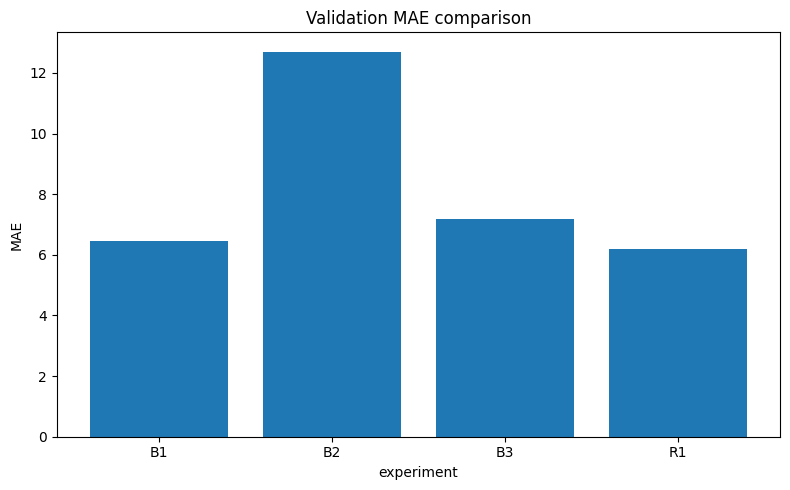

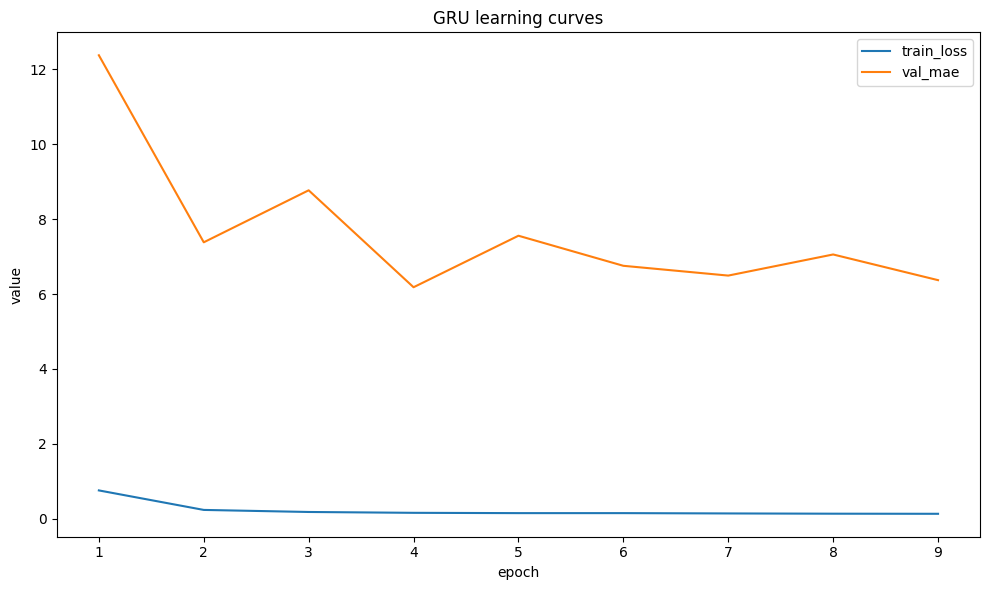

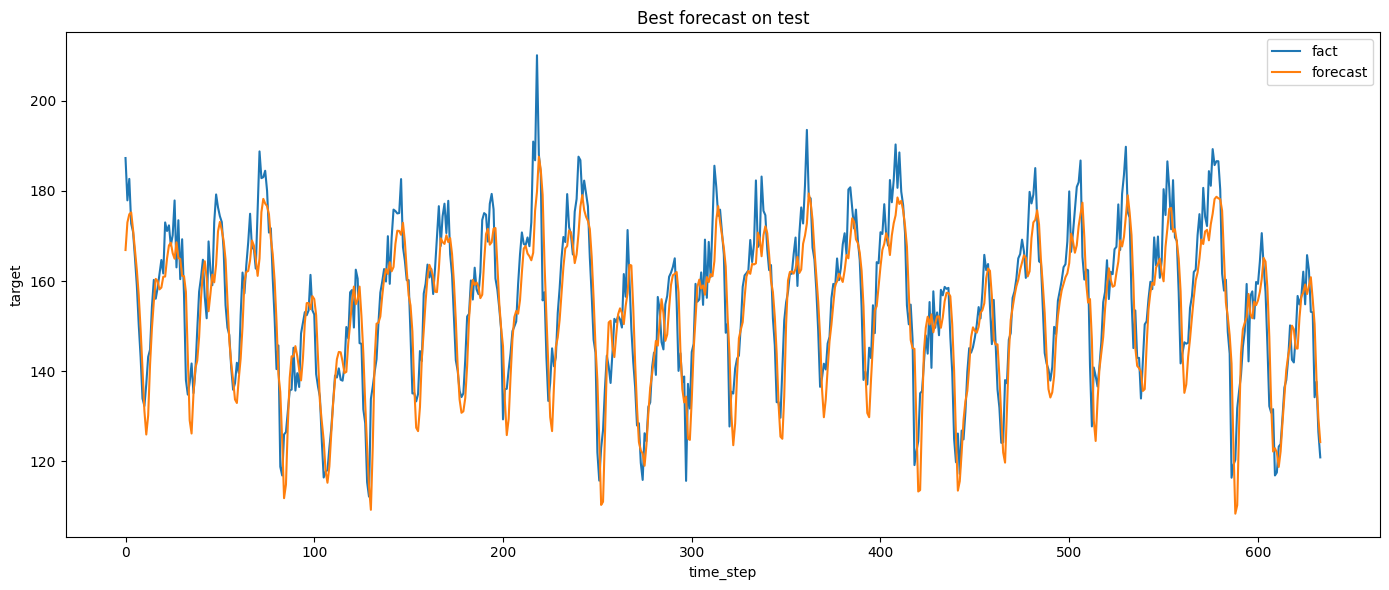


Готово
Лучший эксперимент по validation MAE: R1

Результаты:
  experiment_id  best_val_mae  best_val_rmse  best_val_mape  test_mae  \
0            B1      6.444815       8.201023       4.397922       NaN   
1            B2     12.702013      15.217645       8.816864       NaN   
2            B3      7.188730       8.732282       4.796689       NaN   
3            R1      6.180912       7.804006       4.190495  6.445125   

   test_rmse  test_mape  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3   8.201445   4.202391  


In [3]:
import os
import json
import math
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = Path(".")
DATA_PATH = BASE_DIR / "S12-hw-dataset.csv"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

WINDOW_SIZE = 14
HORIZON = 1
BATCH_SIZE = 64
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.0
LR = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    eps = 1e-8
    return float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100.0)

def compute_metrics(y_true, y_pred):
    return {
        "mae": mae(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred)
    }

def add_time_features(df):
    out = df.copy()
    out["lag_1"] = out["target"].shift(1)
    out["lag_7"] = out["target"].shift(7)
    out["lag_14"] = out["target"].shift(14)
    out["rolling_mean_7"] = out["target"].shift(1).rolling(7).mean()
    out["rolling_std_7"] = out["target"].shift(1).rolling(7).std()
    out["day_of_week"] = out["date"].dt.dayofweek
    return out

class SequenceDataset(Dataset):
    def __init__(self, values_scaled, dates, window_size=14, horizon=1):
        self.X = []
        self.y = []
        self.y_dates = []
        arr = np.asarray(values_scaled, dtype=np.float32).reshape(-1)
        for i in range(window_size, len(arr) - horizon + 1):
            self.X.append(arr[i - window_size:i].reshape(window_size, 1))
            self.y.append(arr[i + horizon - 1])
            self.y_dates.append(dates.iloc[i + horizon - 1])
        self.X = np.asarray(self.X, dtype=np.float32)
        self.y = np.asarray(self.y, dtype=np.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden)
        return pred

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else np.nan

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    preds = []
    trues = []
    for xb, yb in loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy().reshape(-1)
        true = yb.cpu().numpy().reshape(-1)
        preds.extend(pred.tolist())
        trues.extend(true.tolist())
    return np.asarray(trues), np.asarray(preds)

def inverse_transform_1d(scaler, arr):
    arr = np.asarray(arr).reshape(-1, 1)
    return scaler.inverse_transform(arr).reshape(-1)

def evaluate_gru(model, loader, scaler_target, device):
    y_true_scaled, y_pred_scaled = predict_loader(model, loader, device)
    y_true = inverse_transform_1d(scaler_target, y_true_scaled)
    y_pred = inverse_transform_1d(scaler_target, y_pred_scaled)
    return compute_metrics(y_true, y_pred), y_true, y_pred

def fit_gru(train_loader, val_loader, scaler_target, device):
    model = GRUForecast(
        input_size=1,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    history = {
        "epoch": [],
        "train_loss": [],
        "val_mae": [],
        "val_rmse": [],
        "val_mape": []
    }

    best_state = None
    best_val_mae = float("inf")
    best_epoch = 0
    wait = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics, _, _ = evaluate_gru(model, val_loader, scaler_target, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_mae"].append(val_metrics["mae"])
        history["val_rmse"].append(val_metrics["rmse"])
        history["val_mape"].append(val_metrics["mape"])

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_epoch = epoch
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, history, best_epoch

def save_series_split_plot(df, train_end_date, val_end_date, path):
    plt.figure(figsize=(16, 6))
    train_mask = df["date"] <= train_end_date
    val_mask = (df["date"] > train_end_date) & (df["date"] <= val_end_date)
    test_mask = df["date"] > val_end_date

    plt.plot(df.loc[train_mask, "date"], df.loc[train_mask, "target"], label="train")
    plt.plot(df.loc[val_mask, "date"], df.loc[val_mask, "target"], label="validation")
    plt.plot(df.loc[test_mask, "date"], df.loc[test_mask, "target"], label="test")
    plt.title("Series split")
    plt.xlabel("date")
    plt.ylabel("target")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def save_baselines_compare_plot(runs_df, path):
    order = ["B1", "B2", "B3", "R1"]
    dfp = runs_df.set_index("experiment_id").loc[order].reset_index()
    plt.figure(figsize=(8, 5))
    plt.bar(dfp["experiment_id"], dfp["best_val_mae"])
    plt.title("Validation MAE comparison")
    plt.xlabel("experiment")
    plt.ylabel("MAE")
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def save_learning_curves_plot(history, path):
    plt.figure(figsize=(10, 6))
    plt.plot(history["epoch"], history["train_loss"], label="train_loss")
    plt.plot(history["epoch"], history["val_mae"], label="val_mae")
    plt.title("GRU learning curves")
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def save_best_forecast_plot(dates, y_true, y_pred, path):
    plt.figure(figsize=(14, 6))
    plt.plot(np.arange(len(y_true)), y_true, label="fact")
    plt.plot(np.arange(len(y_pred)), y_pred, label="forecast")
    plt.title("Best forecast on test")
    plt.xlabel("time_step")
    plt.ylabel("target")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def save_best_gru(model, path):
    torch.save(model.state_dict(), path)

def save_best_gru_config(path):
    config = {
        "window_size": WINDOW_SIZE,
        "horizon": HORIZON,
        "batch_size": BATCH_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "lr": LR,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "seed": SEED,
        "device": str(DEVICE),
        "scaler": {
            "type": "StandardScaler",
            "fit_on": "train_only"
        }
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=2)

def make_runs_dataframe(results, dataset_name, split_summary, best_exp):
    rows = []

    common = {
        "task": "forecasting",
        "dataset": dataset_name,
        "seed": SEED,
        "split_summary": split_summary,
        "horizon": HORIZON
    }

    rows.append({
        "experiment_id": "B1",
        **common,
        "window_size": np.nan,
        "model_summary": "naive-last",
        "features_summary": "last observed target only",
        "scaler": "none",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": np.nan,
        "best_val_mae": results["B1"]["val"]["mae"],
        "best_val_rmse": results["B1"]["val"]["rmse"],
        "best_val_mape": results["B1"]["val"]["mape"],
        "test_mae": results["B1"]["test"]["mae"] if best_exp == "B1" else np.nan,
        "test_rmse": results["B1"]["test"]["rmse"] if best_exp == "B1" else np.nan,
        "test_mape": results["B1"]["test"]["mape"] if best_exp == "B1" else np.nan,
        "notes": "baseline without training"
    })

    rows.append({
        "experiment_id": "B2",
        **common,
        "window_size": 7,
        "model_summary": "moving-average",
        "features_summary": "mean of previous 7 target values",
        "scaler": "none",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": np.nan,
        "best_val_mae": results["B2"]["val"]["mae"],
        "best_val_rmse": results["B2"]["val"]["rmse"],
        "best_val_mape": results["B2"]["val"]["mape"],
        "test_mae": results["B2"]["test"]["mae"] if best_exp == "B2" else np.nan,
        "test_rmse": results["B2"]["test"]["rmse"] if best_exp == "B2" else np.nan,
        "test_mape": results["B2"]["test"]["mape"] if best_exp == "B2" else np.nan,
        "notes": "baseline without training"
    })

    rows.append({
        "experiment_id": "B3",
        **common,
        "window_size": 14,
        "model_summary": "ridge-lag-features",
        "features_summary": "lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week",
        "scaler": "StandardScaler fit on train only",
        "optimizer": "",
        "lr": np.nan,
        "epochs_trained": np.nan,
        "best_val_mae": results["B3"]["val"]["mae"],
        "best_val_rmse": results["B3"]["val"]["rmse"],
        "best_val_mape": results["B3"]["val"]["mape"],
        "test_mae": results["B3"]["test"]["mae"] if best_exp == "B3" else np.nan,
        "test_rmse": results["B3"]["test"]["rmse"] if best_exp == "B3" else np.nan,
        "test_mape": results["B3"]["test"]["mape"] if best_exp == "B3" else np.nan,
        "notes": "ridge on lag and rolling features"
    })

    rows.append({
        "experiment_id": "R1",
        **common,
        "window_size": WINDOW_SIZE,
        "model_summary": f"GRU(hidden_size={HIDDEN_SIZE}, num_layers={NUM_LAYERS})",
        "features_summary": "window of past target values only",
        "scaler": "StandardScaler fit on train only",
        "optimizer": "Adam",
        "lr": LR,
        "epochs_trained": results["R1"]["epochs_trained"],
        "best_val_mae": results["R1"]["val"]["mae"],
        "best_val_rmse": results["R1"]["val"]["rmse"],
        "best_val_mape": results["R1"]["val"]["mape"],
        "test_mae": results["R1"]["test"]["mae"] if best_exp == "R1" else np.nan,
        "test_rmse": results["R1"]["test"]["rmse"] if best_exp == "R1" else np.nan,
        "test_mape": results["R1"]["test"]["mape"] if best_exp == "R1" else np.nan,
        "notes": "best model selected by validation MAE"
    })

    return pd.DataFrame(rows)

def main():
    print("Устройство:", DEVICE)
    print("Файл данных:", DATA_PATH)

    df = pd.read_csv(DATA_PATH)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    print("\nSanity-check по данным")
    print("Размер датасета:", df.shape)
    print("Диапазон дат:", df["date"].min(), "—", df["date"].max())
    print("Пропуски по колонкам:")
    print(df.isna().sum())
    print("Общее число пропусков:", int(df.isna().sum().sum()))

    plt.figure(figsize=(14, 5))
    plt.plot(df["date"], df["target"])
    plt.title("Исходный временной ряд")
    plt.xlabel("date")
    plt.ylabel("target")
    plt.tight_layout()
    plt.show()
    plt.close()

    print("\nПочему random split некорректен для временного ряда:")
    print("При случайном разбиении модель может обучаться на будущих наблюдениях относительно validation/test,")
    print("что создаёт leakage и делает оценку качества некорректной.")
    print("Поэтому здесь используется только chronological temporal split без shuffle.")

    n = len(df)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    df_train = df.iloc[:train_end].copy()
    df_val = df.iloc[train_end:val_end].copy()
    df_test = df.iloc[val_end:].copy()

    train_end_date = df_train["date"].max()
    val_end_date = df_val["date"].max()

    print("\nГраницы temporal split")
    print("train:", df_train["date"].min(), "—", df_train["date"].max(), f"({len(df_train)} строк)")
    print("validation:", df_val["date"].min(), "—", df_val["date"].max(), f"({len(df_val)} строк)")
    print("test:", df_test["date"].min(), "—", df_test["date"].max(), f"({len(df_test)} строк)")

    save_series_split_plot(df, train_end_date, val_end_date, FIGURES_DIR / "series_split.png")

    split_summary = f"""
temporal split without shuffle:
train: [{df_train["date"].min().date()} ... {df_train["date"].max().date()}] ({len(df_train)} rows, 70%)
validation: [{df_val["date"].min().date()} ... {df_val["date"].max().date()}] ({len(df_val)} rows, 15%)
test: [{df_test["date"].min().date()} ... {df_test["date"].max().date()}] ({len(df_test)} rows, 15%)

split performed chronologically to avoid leakage from future to past
""".strip()

    df_feat = add_time_features(df)

    print("\nПроверка пропусков после построения признаков")
    print(df_feat.isna().sum())

    feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "day_of_week"]

    results = {}

    val_prev = df["target"].shift(1).iloc[train_end:val_end]
    b1_val_mask = val_prev.notna()
    b1_val_y = df.iloc[train_end:val_end].loc[b1_val_mask.values, "target"].values
    b1_val_pred = val_prev.loc[b1_val_mask].values

    test_prev = df["target"].shift(1).iloc[val_end:]
    b1_test_mask = test_prev.notna()
    b1_test_y = df.iloc[val_end:].loc[b1_test_mask.values, "target"].values
    b1_test_pred = test_prev.loc[b1_test_mask].values

    results["B1"] = {
        "val": compute_metrics(b1_val_y, b1_val_pred),
        "test": compute_metrics(b1_test_y, b1_test_pred)
    }

    val_ma = df["target"].shift(1).rolling(7).mean().iloc[train_end:val_end]
    b2_val_mask = val_ma.notna()
    b2_val_y = df.iloc[train_end:val_end].loc[b2_val_mask.values, "target"].values
    b2_val_pred = val_ma.loc[b2_val_mask].values

    test_ma = df["target"].shift(1).rolling(7).mean().iloc[val_end:]
    b2_test_mask = test_ma.notna()
    b2_test_y = df.iloc[val_end:].loc[b2_test_mask.values, "target"].values
    b2_test_pred = test_ma.loc[b2_test_mask].values

    results["B2"] = {
        "val": compute_metrics(b2_val_y, b2_val_pred),
        "test": compute_metrics(b2_test_y, b2_test_pred)
    }

    df_feat_clean = df_feat.dropna().reset_index(drop=True)

    train_max_date = df_train["date"].max()
    val_max_date = df_val["date"].max()

    b3_train = df_feat_clean[df_feat_clean["date"] <= train_max_date].copy()
    b3_val = df_feat_clean[(df_feat_clean["date"] > train_max_date) & (df_feat_clean["date"] <= val_max_date)].copy()
    b3_test = df_feat_clean[df_feat_clean["date"] > val_max_date].copy()

    X_train = b3_train[feature_cols].values
    y_train = b3_train["target"].values
    X_val = b3_val[feature_cols].values
    y_val = b3_val["target"].values
    X_test = b3_test[feature_cols].values
    y_test = b3_test["target"].values

    scaler_b3 = StandardScaler()
    X_train_scaled = scaler_b3.fit_transform(X_train)
    X_val_scaled = scaler_b3.transform(X_val)
    X_test_scaled = scaler_b3.transform(X_test)

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train)

    b3_val_pred = ridge.predict(X_val_scaled)
    b3_test_pred = ridge.predict(X_test_scaled)

    results["B3"] = {
        "val": compute_metrics(y_val, b3_val_pred),
        "test": compute_metrics(y_test, b3_test_pred)
    }

    target_scaler = StandardScaler()

    train_target_scaled = target_scaler.fit_transform(df_train[["target"]]).reshape(-1)
    val_target_scaled = target_scaler.transform(df_val[["target"]]).reshape(-1)
    test_target_scaled = target_scaler.transform(df_test[["target"]]).reshape(-1)

    print("\nПроверка корректного использования scaler")
    print("fit выполнен только на train")
    print("validation/test обработаны только через transform")

    train_seq_ds = SequenceDataset(train_target_scaled, df_train["date"], window_size=WINDOW_SIZE, horizon=HORIZON)
    val_seq_ds = SequenceDataset(val_target_scaled, df_val["date"], window_size=WINDOW_SIZE, horizon=HORIZON)
    test_seq_ds = SequenceDataset(test_target_scaled, df_test["date"], window_size=WINDOW_SIZE, horizon=HORIZON)

    train_loader = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_seq_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_seq_ds, batch_size=BATCH_SIZE, shuffle=False)

    best_gru_model, history, best_epoch = fit_gru(train_loader, val_loader, target_scaler, DEVICE)

    r1_val_metrics, _, _ = evaluate_gru(best_gru_model, val_loader, target_scaler, DEVICE)
    r1_test_metrics, r1_test_true, r1_test_pred = evaluate_gru(best_gru_model, test_loader, target_scaler, DEVICE)

    results["R1"] = {
        "val": r1_val_metrics,
        "test": r1_test_metrics,
        "epochs_trained": best_epoch,
        "model": best_gru_model,
        "history": history,
        "test_true": r1_test_true,
        "test_pred": r1_test_pred
    }

    val_mae_by_exp = {
        "B1": results["B1"]["val"]["mae"],
        "B2": results["B2"]["val"]["mae"],
        "B3": results["B3"]["val"]["mae"],
        "R1": results["R1"]["val"]["mae"]
    }
    best_exp = min(val_mae_by_exp, key=val_mae_by_exp.get)

    save_best_gru(best_gru_model, ARTIFACTS_DIR / "best_gru.pt")
    save_best_gru_config(ARTIFACTS_DIR / "best_gru_config.json")

    runs_df = make_runs_dataframe(results, DATA_PATH.name, split_summary, best_exp)
    runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False, encoding="utf-8")

    save_baselines_compare_plot(runs_df, FIGURES_DIR / "baselines_compare.png")
    save_learning_curves_plot(history, FIGURES_DIR / "gru_learning_curves.png")
    save_best_forecast_plot(df_test["date"].iloc[WINDOW_SIZE:].reset_index(drop=True), r1_test_true, r1_test_pred, FIGURES_DIR / "best_forecast_test.png")

    print("\nГотово")
    print("Лучший эксперимент по validation MAE:", best_exp)
    print("\nРезультаты:")
    print(runs_df[[
        "experiment_id",
        "best_val_mae",
        "best_val_rmse",
        "best_val_mape",
        "test_mae",
        "test_rmse",
        "test_mape"
    ]])

if __name__ == "__main__":
    main()